# EDA — Fraud Detection Transactions Dataset

Базовый разведочный анализ датасета транзакций.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

## 1. Загрузка данных

In [4]:
df = pd.read_csv('synthetic_fraud_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 21)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


## 2. Общая информация

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [6]:
df.describe().round(2)

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,99.41,50294.07,0.05,0.1,7.49,255.27,2.00,120.00,2499.16,0.50,0.30,0.32
std,98.69,28760.46,0.22,0.3,4.04,141.38,1.41,68.99,1442.01,0.29,0.46,0.47
min,0.00,500.48,0.00,0.0,1.00,10.00,0.00,1.00,0.25,0.00,0.00,0.00
25%,28.68,25356.00,0.00,0.0,4.00,132.09,1.00,60.00,1256.50,0.25,0.00,0.00
50%,69.66,50384.43,0.00,0.0,7.00,256.08,2.00,120.00,2490.78,0.50,0.00,0.00
75%,138.85,75115.14,0.00,0.0,11.00,378.03,3.00,180.00,3746.40,0.75,1.00,1.00
max,1174.14,99998.31,1.00,1.0,14.00,500.00,4.00,239.00,4999.93,1.00,1.00,1.00


In [7]:
# Пропущенные значения
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропущенных значений нет")

Пропущенных значений нет


In [8]:
# Дубликаты
print(f"Дубликатов: {df.duplicated().sum()}")

Дубликатов: 0


## 3. Целевая переменная — Fraud_Label

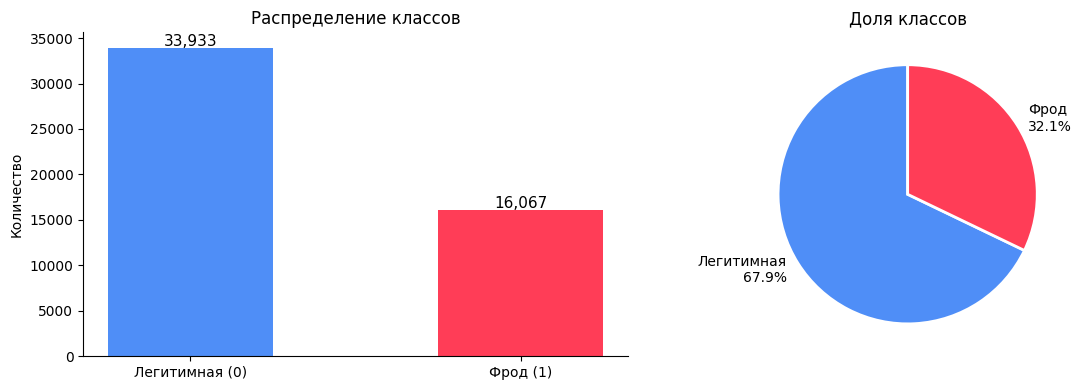

Fraud rate: 32.13%


In [19]:
counts = df['Fraud_Label'].value_counts()
pct = df['Fraud_Label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Легитимная (0)', 'Фрод (1)'], counts.values, color=['#4f8ef7','#ff3d57'], width=0.5)
axes[0].set_title('Распределение классов')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

label_legit = f'Легитимная\n{pct[0]:.1f}%'
label_fraud = f'Фрод\n{pct[1]:.1f}%'

axes[1].pie(pct.values, labels=[label_legit, label_fraud],
            colors=['#4f8ef7','#ff3d57'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.show()
print(f"Fraud rate: {pct[1]:.2f}%")

## 4. Числовые признаки

In [12]:
num_cols = ['Transaction_Amount','Account_Balance','Daily_Transaction_Count',
            'Avg_Transaction_Amount_7d','Failed_Transaction_Count_7d',
            'Card_Age','Transaction_Distance','Risk_Score']

df[num_cols].describe().round(2)

,Transaction_Amount,Account_Balance,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,99.41,50294.07,7.49,255.27,2.00,120.00,2499.16,0.50
std,98.69,28760.46,4.04,141.38,1.41,68.99,1442.01,0.29
min,0.00,500.48,1.00,10.00,0.00,1.00,0.25,0.00
25%,28.68,25356.00,4.00,132.09,1.00,60.00,1256.50,0.25
50%,69.66,50384.43,7.00,256.08,2.00,120.00,2490.78,0.50
75%,138.85,75115.14,11.00,378.03,3.00,180.00,3746.40,0.75
max,1174.14,99998.31,14.00,500.00,4.00,239.00,4999.93,1.00


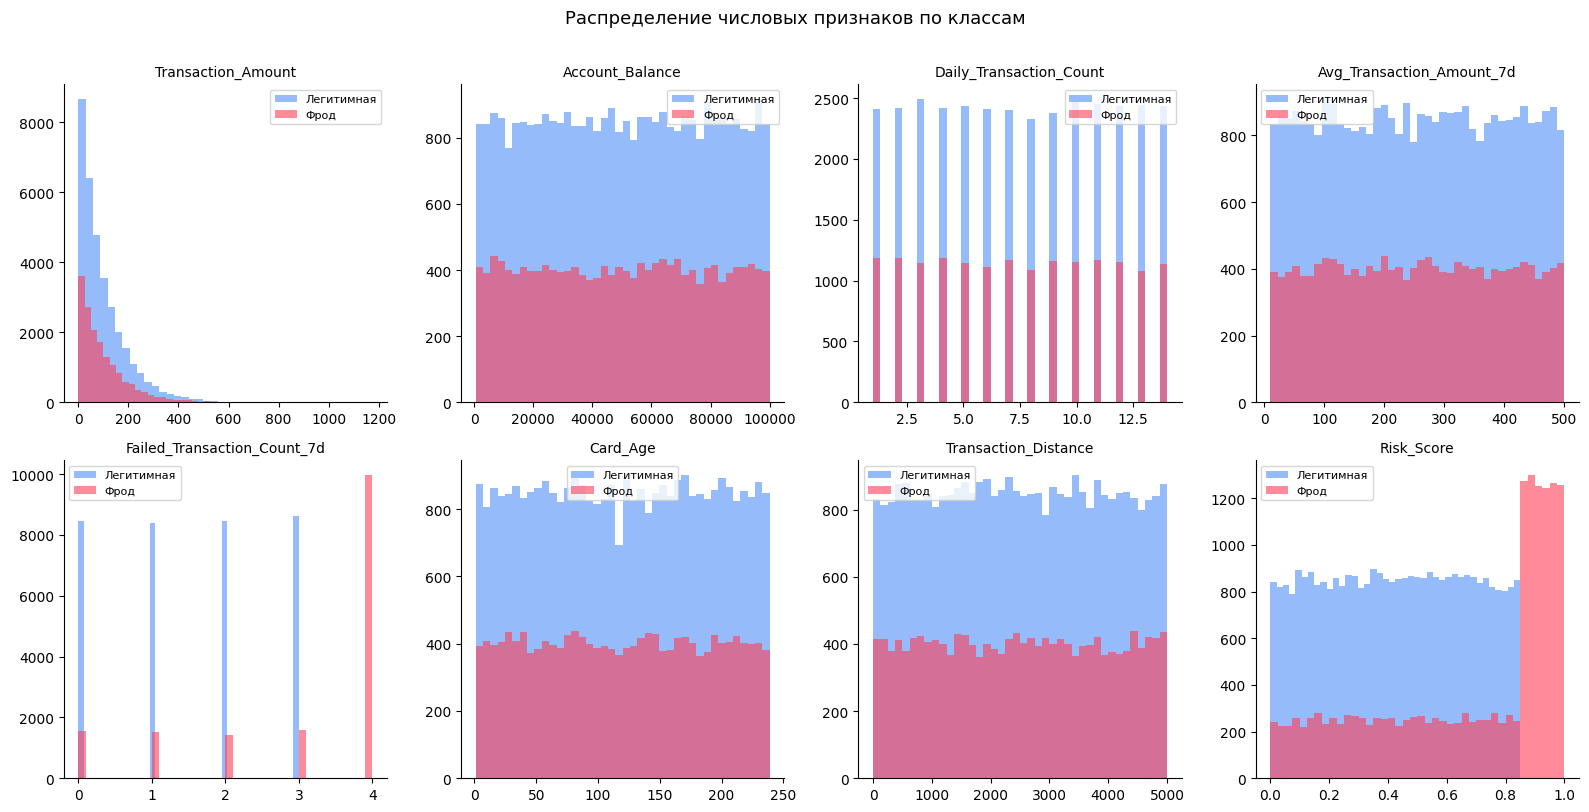

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['Fraud_Label']==0][col], bins=40, alpha=0.6, color='#4f8ef7', label='Легитимная')
    axes[i].hist(df[df['Fraud_Label']==1][col], bins=40, alpha=0.6, color='#ff3d57', label='Фрод')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Распределение числовых признаков по классам', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Категориальные признаки

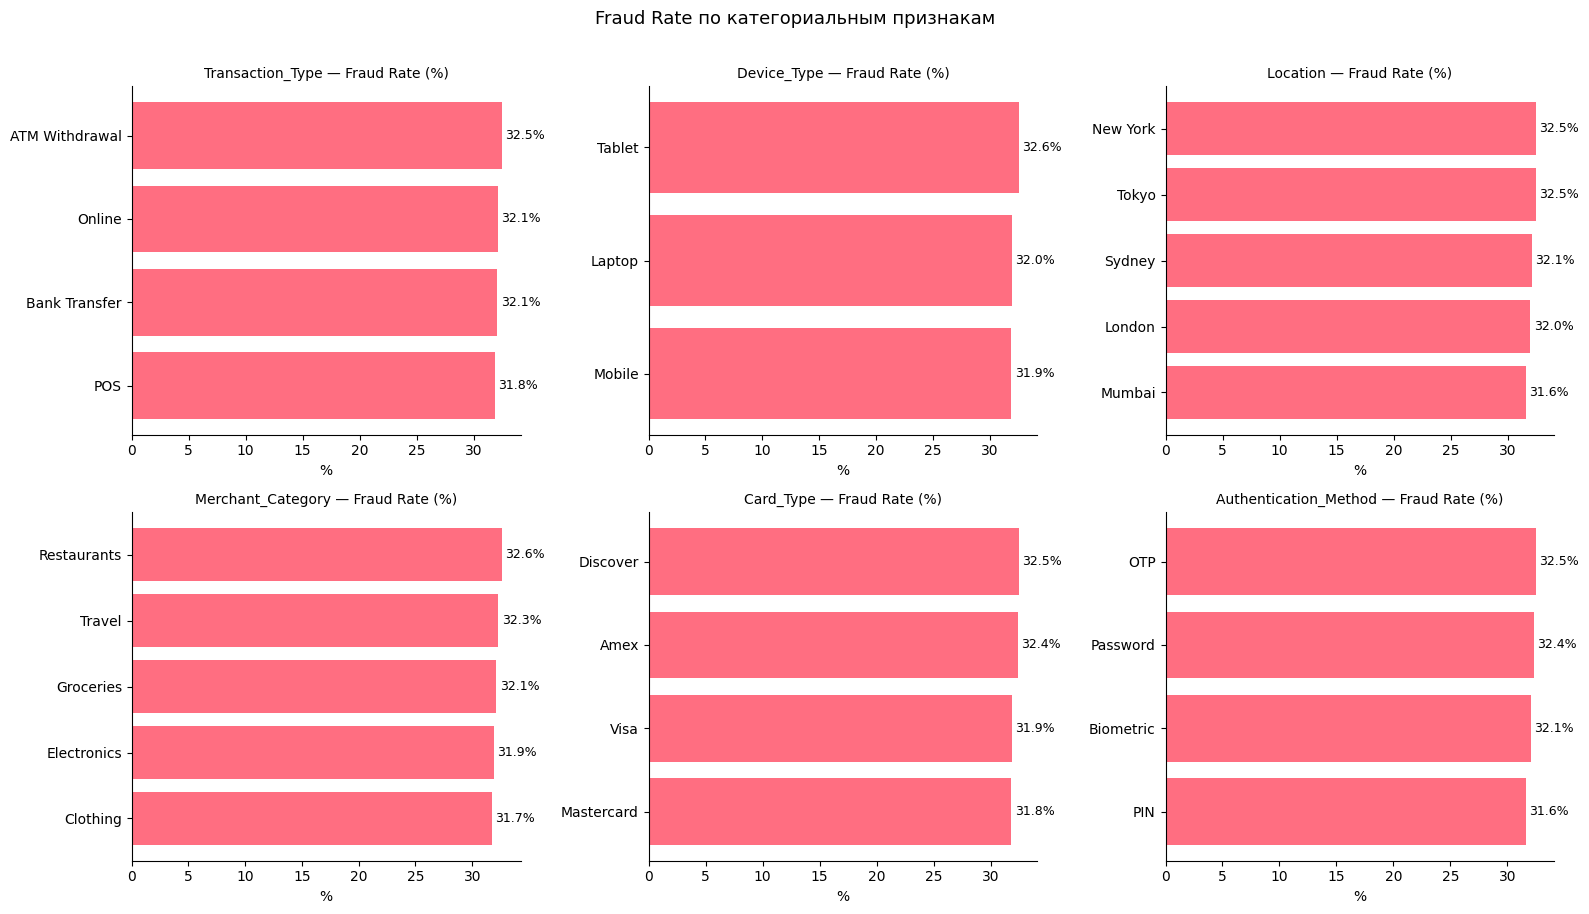

In [14]:
cat_cols = ['Transaction_Type','Device_Type','Location',
            'Merchant_Category','Card_Type','Authentication_Method']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    data = df.groupby(col)['Fraud_Label'].agg(['sum','count'])
    data['fraud_rate'] = data['sum'] / data['count'] * 100
    data = data.sort_values('fraud_rate', ascending=True)

    bars = axes[i].barh(data.index, data['fraud_rate'], color='#ff3d57', alpha=0.75)
    axes[i].set_title(f'{col} — Fraud Rate (%)', fontsize=10)
    axes[i].set_xlabel('%')
    for bar, val in zip(bars, data['fraud_rate']):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     f"{val:.1f}%", va='center', fontsize=9)

plt.suptitle('Fraud Rate по категориальным признакам', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Корреляционная матрица

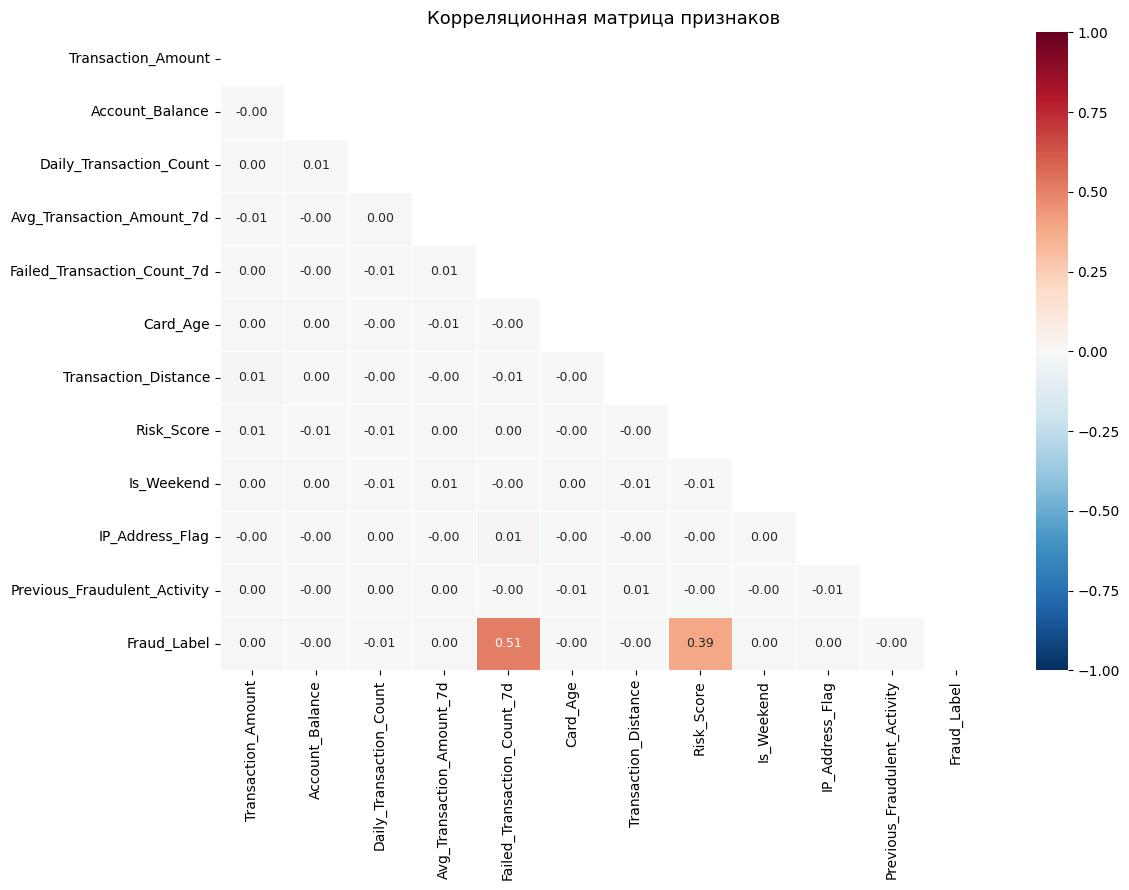

In [15]:
corr_cols = num_cols + ['Is_Weekend','IP_Address_Flag','Previous_Fraudulent_Activity','Fraud_Label']
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Корреляционная матрица признаков', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Корреляция с целевой переменной
corr_target = df[corr_cols].corr()['Fraud_Label'].drop('Fraud_Label').sort_values(key=abs, ascending=False)
print("Корреляция с Fraud_Label:")
print(corr_target.round(4).to_string())

Корреляция с Fraud_Label:
Failed_Transaction_Count_7d     0.5099
Risk_Score                      0.3858
Daily_Transaction_Count        -0.0071
Account_Balance                -0.0032
Card_Age                       -0.0031
IP_Address_Flag                 0.0030
Transaction_Amount              0.0019
Previous_Fraudulent_Activity   -0.0007
Avg_Transaction_Amount_7d       0.0007
Transaction_Distance           -0.0001
Is_Weekend                      0.0001


## 7. Анализ по времени

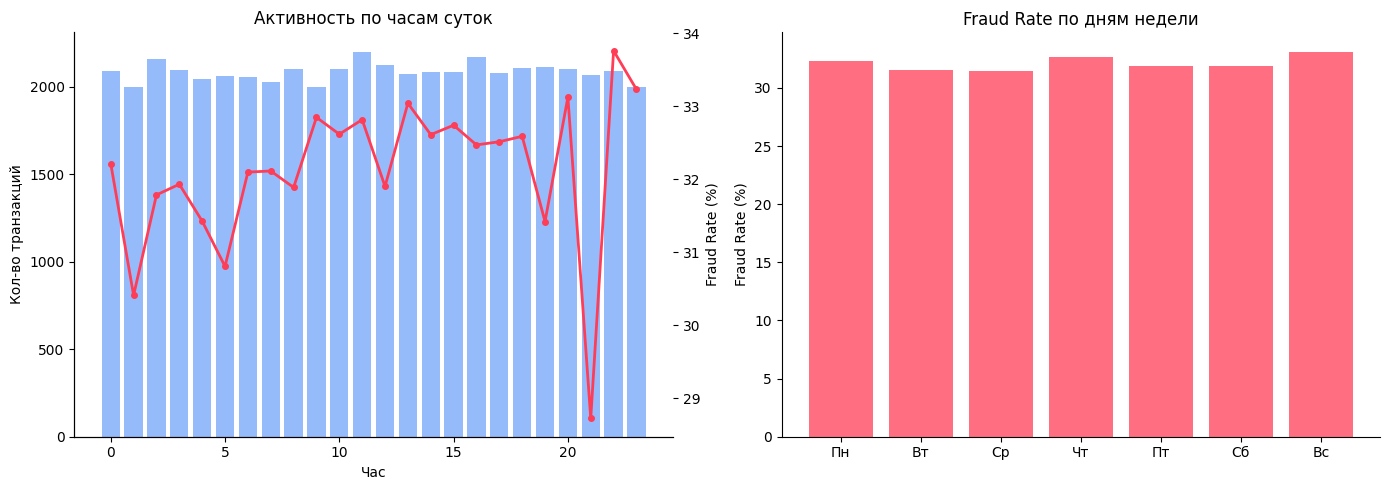

In [17]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По часам
hour_stats = df.groupby('Hour')['Fraud_Label'].agg(['sum','count'])
hour_stats['fraud_rate'] = hour_stats['sum'] / hour_stats['count'] * 100
axes[0].bar(hour_stats.index, hour_stats['count'], color='#4f8ef7', alpha=0.6, label='Всего')
ax2 = axes[0].twinx()
ax2.plot(hour_stats.index, hour_stats['fraud_rate'], color='#ff3d57', linewidth=2, marker='o', markersize=4, label='Fraud %')
axes[0].set_title('Активность по часам суток')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('Кол-во транзакций')
ax2.set_ylabel('Fraud Rate (%)')

# По дням недели
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_stats = df.groupby('DayOfWeek')['Fraud_Label'].agg(['sum','count']).reindex(day_order)
day_stats['fraud_rate'] = day_stats['sum'] / day_stats['count'] * 100
axes[1].bar(range(7), day_stats['fraud_rate'], color='#ff3d57', alpha=0.75)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])
axes[1].set_title('Fraud Rate по дням недели')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

## 8. Сводная статистика по группам

In [18]:
summary = df.groupby('Fraud_Label').agg(
    count=('Transaction_Amount','count'),
    avg_amount=('Transaction_Amount','mean'),
    avg_balance=('Account_Balance','mean'),
    avg_distance=('Transaction_Distance','mean'),
    avg_risk=('Risk_Score','mean'),
    avg_failed_7d=('Failed_Transaction_Count_7d','mean'),
    ip_flag_rate=('IP_Address_Flag','mean'),
    prev_fraud_rate=('Previous_Fraudulent_Activity','mean'),
).round(2)
summary.index = ['Легитимная','Фрод']
summary

,count,avg_amount,avg_balance,avg_distance,avg_risk,avg_failed_7d,ip_flag_rate,prev_fraud_rate
Легитимная,33933,99.28,50356.47,2499.28,0.43,1.51,0.05,0.1
Фрод,16067,99.68,50162.26,2498.92,0.66,3.05,0.05,0.1


## 9. Выводы

- **Дисбаланс классов**: ~32% фрода — умеренный дисбаланс, модель обучается без oversampling
- **Ключевые числовые признаки**: , ,  имеют наибольшую корреляцию с фродом
- **Категориальные признаки**: fraud rate относительно равномерен по городам, типам устройств и картам — признаки слабо дискриминативны сами по себе
- **Время**: нет выраженных пиков фрода по часам или дням — транзакции распределены равномерно (синтетический датасет)
- **Risk_Score**: содержит утечку данных (data leakage) — коррелирует с Fraud_Label напрямую, в ML-модели не используется